<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/EPH_aglomerados_puntos_random.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import random
import geopandas as gpd
from shapely.geometry import Polygon, Point
from pyproj import Transformer


from shapely.geometry import Polygon, Point
import random
import geopandas as gpd
import numpy as np

def generar_puntos_interior_no_superpuestos(coordenadas_latlon, n=50, distancia_min_m=200, max_iter=10000):
    if len(coordenadas_latlon) < 3:
        raise ValueError("Se requieren al menos 3 coordenadas para formar un polígono.")

    # Crear el polígono en lat/lon
    poligono_wgs84 = Polygon(coordenadas_latlon)
    gdf = gpd.GeoDataFrame(geometry=[poligono_wgs84], crs="EPSG:4326")

    # Convertir a sistema métrico (UTM estimado automáticamente)
    gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())
    poligono_utm = gdf_utm.geometry.values[0]

    # Generar el buffer negativo para evitar bordes
    interior_utm = poligono_utm.buffer(-distancia_min_m)

    if interior_utm.is_empty:
        raise ValueError("El polígono es demasiado pequeño para aplicar un buffer de {} metros.".format(distancia_min_m))

    minx, miny, maxx, maxy = interior_utm.bounds

    puntos = []
    intentos = 0

    while len(puntos) < n and intentos < max_iter:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        nuevo_punto = Point(x, y)

        if not interior_utm.contains(nuevo_punto):
            intentos += 1
            continue

        # Verificar que esté al menos a distancia_min_m de todos los puntos existentes
        if all(nuevo_punto.distance(p) >= distancia_min_m for p in puntos):
            puntos.append(nuevo_punto)

        intentos += 1

    if len(puntos) < n:
        print(f"⚠️ Solo se generaron {len(puntos)} puntos tras {max_iter} intentos.")

    # Convertir a lat/lon
    puntos_gdf = gpd.GeoSeries(puntos, crs=gdf_utm.crs).to_crs("EPSG:4326")
    return [[p.y, p.x] for p in puntos_gdf]  # lat, lon


In [2]:
import requests, zipfile, io
import geopandas as gpd

!wget "https://www.indec.gob.ar/ftp/cuadros/territorio/radios_eph.zip"
!unzip 'radios_eph.zip'

gdf = gpd.read_file('radios_eph.shp')

# Pasar a WGS84 (lat/lon)
gdf = gdf.to_crs(epsg=4326)

--2025-06-17 17:31:02--  https://www.indec.gob.ar/ftp/cuadros/territorio/radios_eph.zip
Resolving www.indec.gob.ar (www.indec.gob.ar)... 186.33.230.196
Connecting to www.indec.gob.ar (www.indec.gob.ar)|186.33.230.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4737135 (4.5M) [application/x-zip-compressed]
Saving to: ‘radios_eph.zip’

radios_eph.zip      100%[===================>]   4.52M  3.19MB/s    in 1.4s    

2025-06-17 17:31:04 (3.19 MB/s) - ‘radios_eph.zip’ saved [4737135/4737135]

Archive:  radios_eph.zip
  inflating: radios_eph.shx          
  inflating: wfsrequest.txt          
  inflating: radios_eph.shp          
  inflating: radios_eph.cst          
  inflating: radios_eph.prj          
  inflating: radios_eph.dbf          


In [3]:
aglomerados_dict = {
    2: "Gran La Plata",
    3: "Bahía Blanca-Cerri",
    4: "Gran Rosario",
    5: "Gran Santa Fe",
    6: "Gran Paraná",
    7: "Posadas",
    8: "Gran Resistencia",
    9: "Comodoro Rivadavia-Rada Tilly",
    10: "Gran Mendoza",
    12: "Corrientes",
    13: "Gran Córdoba",
    14: "Concordia",
    15: "Formosa",
    17: "Neuquén-Plottier",
    18: "Santiago del Estero-La Banda",
    19: "Jujuy-Palpalá",
    20: "Río Gallegos",
    22: "Gran Catamarca",
    23: "Gran Salta",
    25: "La Rioja",
    26: "Gran San Luis",
    27: "Gran San Juan",
    29: "Gran Tucumán-Tafí Viejo",
    30: "Santa Rosa-Toay",
    31: "Ushuaia-Río Grande",
    32: "Ciudad Autónoma de Buenos Aires",
    33: "Partidos del Gran Buenos Aires",
    34: "Mar del Plata",
    36: "Río Cuarto",
    38: "San Nicolás-Villa Constitución",
    91: "Rawson-Trelew",
    93: "Viedma-Carmen de Patagones"
}

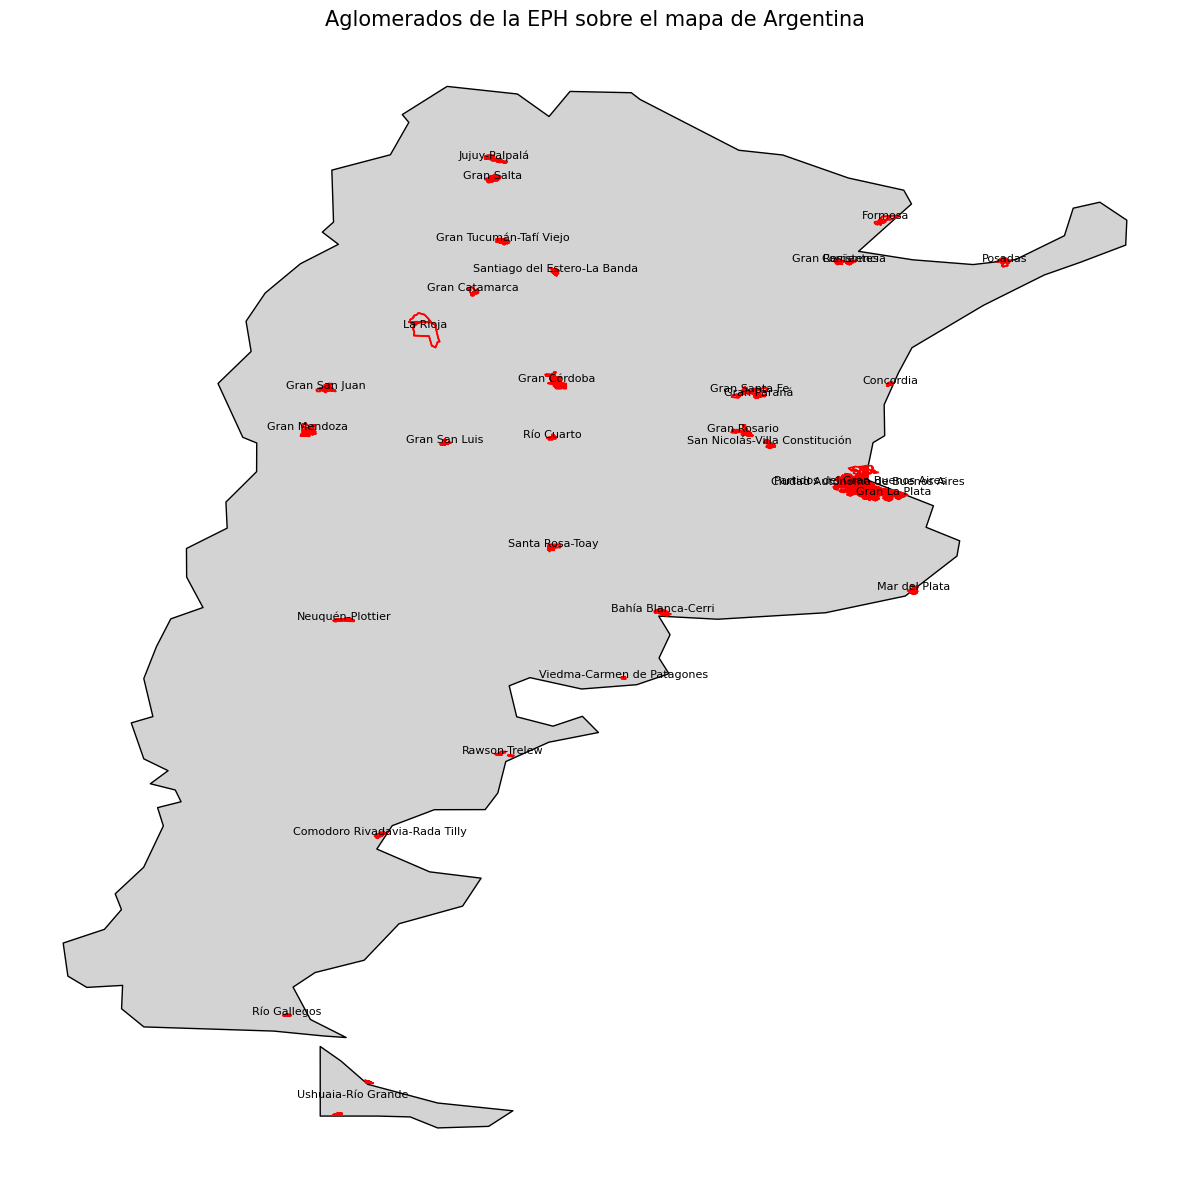

In [5]:
import requests, zipfile, io
import geopandas as gpd
import matplotlib.pyplot as plt

# Usamos un GeoJSON de los límites administrativos de Argentina (nivel país)
limites_pais = gpd.read_file("https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson")
argentina = limites_pais[limites_pais['admin'] == 'Argentina'].to_crs(epsg=4326)

# Encontrar el archivo .shp dentro del zip
#shp_path = [name for name in z.namelist() if name.endswith(".shp")][0]

# --- Filtrar aglomerados ---
gdf["eph_codagl"] = gdf["eph_codagl"].astype("Int64")
gdf_filtrado = gdf[gdf["eph_codagl"].isin(aglomerados_dict.keys())].copy()

# Limpiar geometrías inválidas
gdf_filtrado = gdf_filtrado[gdf_filtrado.geometry.notnull() & ~gdf_filtrado.is_empty]
gdf_filtrado = gdf_filtrado[gdf_filtrado.is_valid]


# 🔁 Parte 2: Asegurar CRS de tus aglomerados filtrados
gdf_filtrado = gdf_filtrado.to_crs(epsg=4326)

# 🔎 Parte 3: Graficar solo contornos
fig, ax = plt.subplots(figsize=(12, 12))

# Fondo gris claro: mapa de Argentina
argentina.plot(ax=ax, color="lightgray", edgecolor="black")

# Contornos de los aglomerados: sin color de relleno
gdf_filtrado.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.2)

# Etiquetas
for cod, nombre in aglomerados_dict.items():
    aglo = gdf_filtrado[gdf_filtrado["eph_codagl"] == cod]
    if not aglo.empty:
        centroide = aglo.geometry.union_all().centroid
        ax.text(centroide.x, centroide.y, nombre, fontsize=8, ha="center", color="black")

ax.set_title("Aglomerados de la EPH sobre el mapa de Argentina", fontsize=15)
ax.set_axis_off()
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

In [13]:
from shapely.geometry import Polygon
import random

# Diccionario donde guardaremos los puntos por aglomerado
puntos_por_aglomerado = {}


# Agrupamos por aglomerado y unimos los polígonos de cada uno
gdf_aglomerados = gdf_filtrado.dissolve(by="eph_codagl")

for codagl, row in gdf_aglomerados.iterrows():
    nombre = aglomerados_dict.get(codagl, f"Aglomerado {codagl}")
    geom = row.geometry

    # Asegurarnos de que sea un solo polígono
    if geom.geom_type == 'MultiPolygon':
        geom = max(geom.geoms, key=lambda g: g.area)

    coords = list(geom.exterior.coords)

    try:
        puntos = generar_puntos_interior_no_superpuestos(coords, n=50, distancia_min_m=200)
        puntos_por_aglomerado[codagl] = puntos
    except ValueError as e:
        print(f"[{nombre}] No se pudieron generar puntos: {e}")


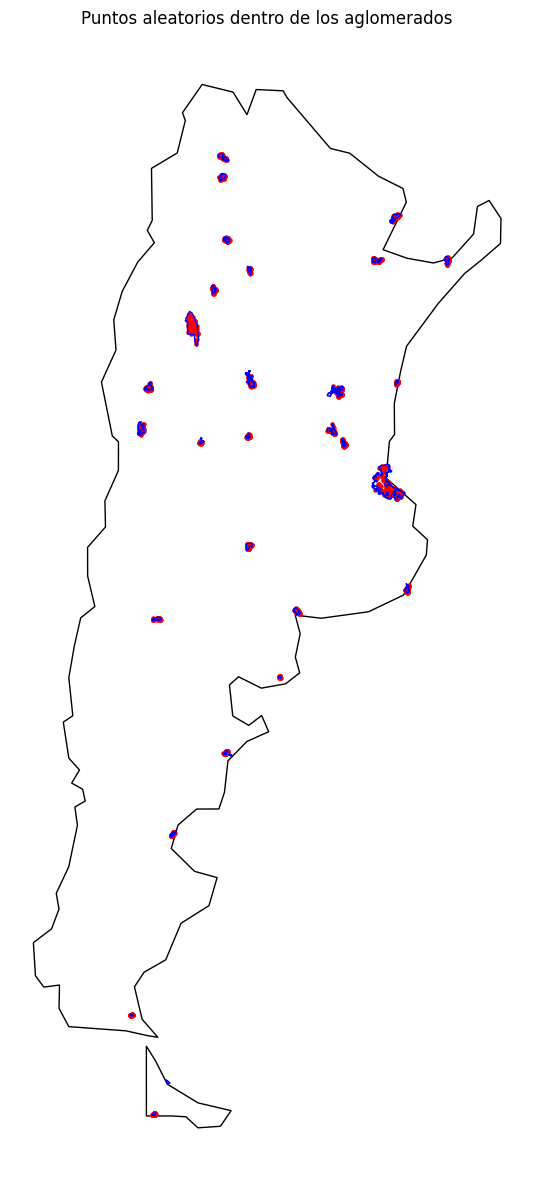

In [14]:
fig, ax = plt.subplots(figsize=(12, 12))
argentina.plot(ax=ax, color="white", edgecolor="black")
gdf_aglomerados.boundary.plot(ax=ax, color="blue", linewidth=1)

# Plotear puntos
for codagl, puntos in puntos_por_aglomerado.items():
    puntos_geom = [Point(lon, lat) for lat, lon in puntos]
    gpd.GeoSeries(puntos_geom, crs="EPSG:4326").plot(ax=ax, markersize=5, color="red")

plt.title("Puntos aleatorios dentro de los aglomerados")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

datos_aglomerados = []

for codagl, row in gdf_aglomerados.iterrows():
    nombre = aglomerados_dict.get(codagl, f"Aglomerado {codagl}")

    # Buscar alguna info adicional: tomamos la provincia de gdf_filtrado
    prov = gdf_filtrado[gdf_filtrado["eph_codagl"] == codagl]["nomprov"].mode().values[0]

    geom = row.geometry
    if geom.geom_type == 'MultiPolygon':
        geom = max(geom.geoms, key=lambda g: g.area)

    coords = list(geom.exterior.coords)

    try:
        puntos = generar_puntos_interior_no_superpuestos(coords, n=50, distancia_min_m=200)
        datos_aglomerados.append({
            "codigo": codagl,
            "nombre": nombre,
            "provincia": prov,
            "puntos_latlon": puntos
        })
    except ValueError as e:
        print(f"⚠️ [{nombre}] No se pudieron generar puntos: {e}")


In [18]:
df_puntos_aglomerados = pd.DataFrame(datos_aglomerados)

In [19]:
df_puntos_aglomerados

,codigo,nombre,provincia,puntos_latlon
0,2,Gran La Plata,Buenos Aires,"[[-34.95885496316042, -58.03582028106166], [-3..."
1,3,Bahía Blanca-Cerri,Buenos Aires,"[[-38.67804009469037, -62.26328184127803], [-3..."
2,4,Gran Rosario,Santa Fe,"[[-32.872139720554124, -60.81973185282602], [-..."
3,5,Gran Santa Fe,Santa Fe,"[[-31.540001265869208, -60.54073601808394], [-..."
4,6,Gran Paraná,Entre Ríos,"[[-31.75982187646382, -60.35688574728254], [-3..."
5,7,Posadas,Misiones,"[[-27.484187752994995, -55.88980414210001], [-..."
6,8,Gran Resistencia,Chaco,"[[-27.489852423159867, -59.017157887397985], [..."
7,9,Comodoro Rivadavia-Rada Tilly,Chubut,"[[-45.881967564937156, -67.50918113689379], [-..."
8,10,Gran Mendoza,Mendoza,"[[-32.69141818829694, -68.9560370804885], [-32..."
9,12,Corrientes,Corrientes,"[[-27.48186428057838, -58.76531212981394], [-2..."
